# Análisis del corpus
## Autor: Yasin Hanin Boukaddidi

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("tcga_simple_train.csv")
df.head()

,patient_id,text,t
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3


In [ ]:
df.keys()

Index(['patient_id', 'text', 't'], dtype='object')

### Análisis Exploratorio de Datos (EDA)
En esta sección, examinaremos la calidad de los datos, la distribución de las categorías de tumor ('t') y las propiedades del texto médico.

In [ ]:
# 1. Información general y valores nulos
print("--- Estructura del Dataset ---")
display(df.info())

print("\n--- Conteo de Valores Faltantes ---")
display(df.isnull().sum())

--- Estructura del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5158 entries, 0 to 5157
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   patient_id   5158 non-null   object
 1   text         5158 non-null   object
 2   t            5158 non-null   object
 3   text_length  5158 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 161.3+ KB


None


--- Conteo de Valores Faltantes ---


,0
patient_id,0
text,0
t,0
text_length,0


--- Distribución de Categorías (Columna 't') ---


,count
t,
T1,1302
T2,1752
T3,1583
T4,521


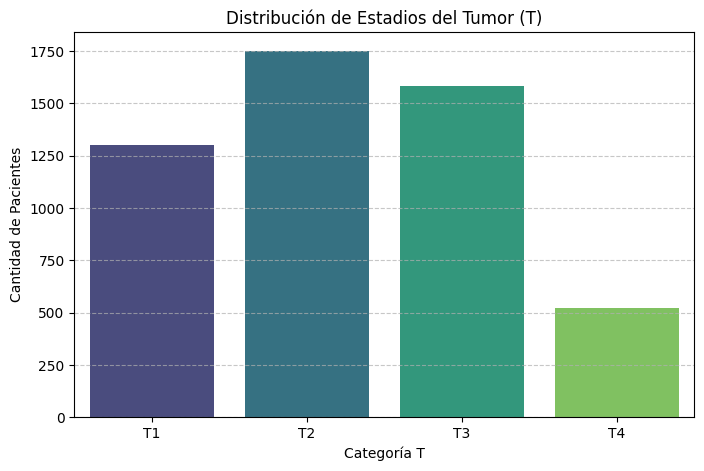

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Análisis de la variable objetivo 't'
print("--- Distribución de Categorías (Columna 't') ---")
t_counts = df['t'].value_counts().sort_index()
display(t_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=t_counts.index, y=t_counts.values, palette='viridis', hue=t_counts.index, legend=False)
plt.title('Distribución de Estadios del Tumor (T)')
plt.xlabel('Categoría T')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- Estadísticas de Longitud de Texto ---


,longitud_texto
count,5158.000000
mean,3568.373207
std,3074.859780
min,85.000000
25%,1160.000000
50%,2835.000000
75%,4958.500000
max,25640.000000


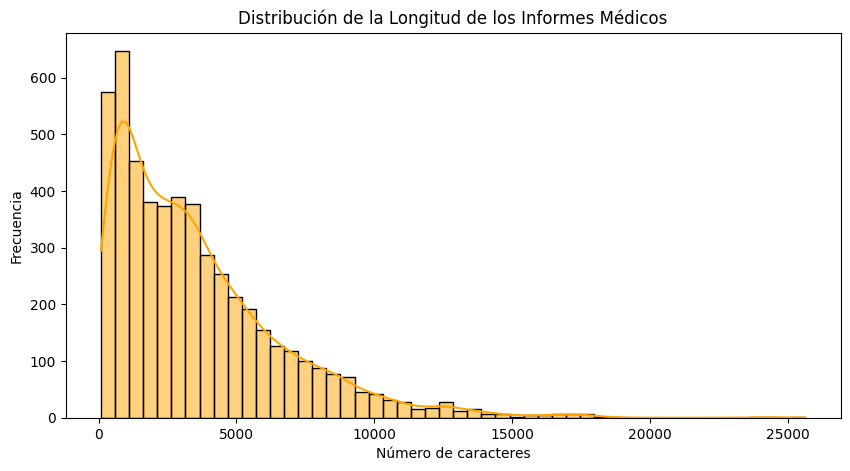

In [ ]:
# 3. Análisis de la longitud del texto
df['longitud_texto'] = df['text'].apply(lambda x: len(str(x)))

print("--- Estadísticas de Longitud de Texto ---")
display(df['longitud_texto'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['longitud_texto'], bins=50, kde=True, color='orange')
plt.title('Distribución de la Longitud de los Informes Médicos')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.show()

--- Estadísticas de Longitud de Texto (Palabras) ---


,longitud_palabras
count,5158.000000
mean,546.435440
std,482.666821
min,11.000000
25%,162.000000
50%,430.500000
75%,765.000000
max,3862.000000


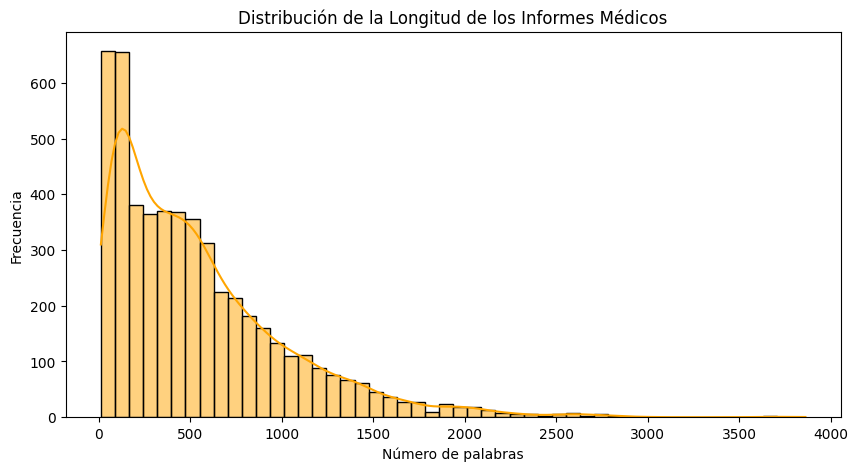

In [ ]:
# 3. Análisis de la longitud del texto (palabras/tokens)
df['longitud_palabras'] = df['text'].apply(lambda x: len(str(x).split()))

print("--- Estadísticas de Longitud de Texto (Palabras) ---")
display(df['longitud_palabras'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['longitud_palabras'], bins=50, kde=True, color='orange')
plt.title('Distribución de la Longitud de los Informes Médicos')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.show()

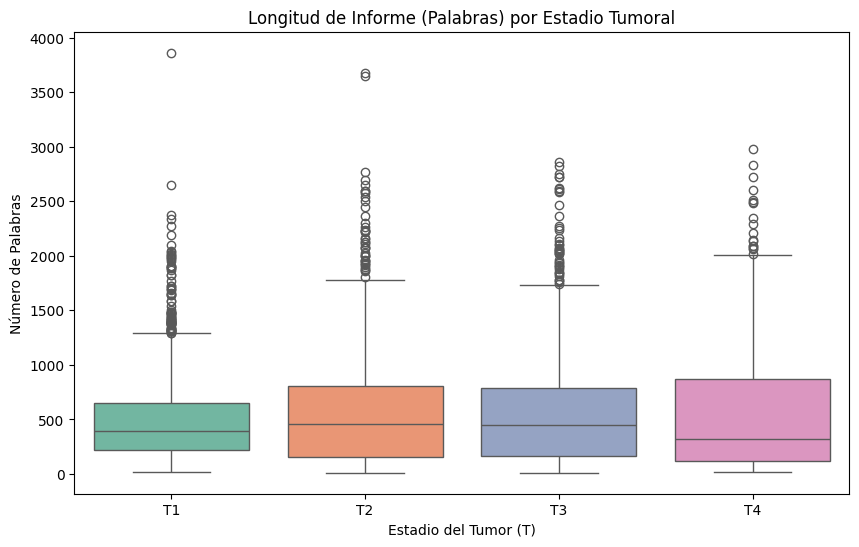

--- Promedio de palabras por estadio ---
t
T1    501.200461
T2    556.528539
T3    559.611497
T4    585.504798
Name: longitud_palabras, dtype: float64


In [ ]:
# 4. Comparación de longitud de palabras por estadio tumoral
plt.figure(figsize=(10, 6))
sns.boxplot(x='t', y='longitud_palabras', data=df.sort_values('t'), palette='Set2', hue='t', legend=False)
plt.title('Longitud de Informe (Palabras) por Estadio Tumoral')
plt.xlabel('Estadio del Tumor (T)')
plt.ylabel('Número de Palabras')
plt.show()

# Mostrar promedios por grupo
print("--- Promedio de palabras por estadio ---")
print(df.groupby('t')['longitud_palabras'].mean())

In [ ]:
# Calcular y mostrar la mediana de palabras por estadio
print("--- Mediana de palabras por estadio ---")
mediana_palabras = df.groupby('t')['longitud_palabras'].median()
display(mediana_palabras)

# Agregar una línea para visualizar la mediana general en el boxplot
print(f"\nMediana general del dataset: {df['longitud_palabras'].median()} palabras.")

--- Mediana de palabras por estadio ---


,longitud_palabras
t,
T1,398.0
T2,454.0
T3,451.0
T4,322.0



Mediana general del dataset: 430.5 palabras.
